# DDROM for MHD: Online Phase - 2
This notebook implements the Online Phase in which the snapshots are reconstructued using POD-GPR vs POD-projection.

In [1]:
import numpy as np
import os
from mpi4py import MPI
from dolfinx.io import gmshio
from dolfinx.fem import (FunctionSpace, locate_dofs_topological, Function)
import pickle
import gmsh
import ufl
import vtk
import pyvista as pv
import dolfinx

pv.start_xvfb()

from pyforce.tools.write_read import ImportH5, StoreFunctionsList as store
from pyforce.tools.functions_list import FunctionsList, train_test_split
from pyforce.online.pod_projection import POD_project
from pyforce.online.pod_interpolation import PODI

import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib import cm

plt.rcParams.update({
  "text.usetex": True,
  "font.family": "serif"
})

rcParams['text.latex.preamble'] = r'\usepackage{amssymb} \usepackage{amsmath} \usepackage{amsthm} \usepackage{mathtools}'

path_off='./Offline_results/'
path='./Online_results/Test/'
if not os.path.exists(path):
    os.makedirs(path)

## Mesh
The mesh is loaded and the constrained sensors positions are selected (different regions or boundaries can be used).

In [2]:
mesh_comm = MPI.COMM_WORLD
model_rank = 0

# Initialize the gmsh module
gmsh.initialize()

# Load the .geo file
gmsh.merge('BFS2D.geo')
gmsh.model.geo.synchronize()

# Set algorithm (adaptive = 1, Frontal-Delaunay = 6)
gmsh.option.setNumber("Mesh.Algorithm", 6)
gdim = 2

# Linear Finite Element
gmsh.model.mesh.generate(gdim)
gmsh.model.mesh.optimize("Netgen")

# Import into dolfinx
model_rank = 0
domain, ct, ft = gmshio.model_to_mesh(gmsh.model, MPI.COMM_WORLD, model_rank, gdim = gdim )
gmsh.finalize()

########################################################################################################

tdim = domain.topology.dim
fdim = tdim - 1
domain.topology.create_connectivity(fdim, tdim)

# Defining functional spaces
vecEl = ufl.VectorElement("CG", domain.ufl_cell(), 1)

fun_spaces = [FunctionSpace(domain, ("Lagrange", 1)), FunctionSpace(domain, vecEl)]
# fun_spaces = [FunctionSpace(domain, vecEl)]

var_names = ['p_red', 'U']
tex_var_names = [r'\tilde{p}', r'\mathbf{u}']

# darth_vader = Function(V)
# emperor = Function(V)
# darth_vader.vector.axpy(1., emperor.vector)
path_FOM = './Snapshots/Test/'

Info    : Reading 'BFS2D.geo'...
Info    : Done reading 'BFS2D.geo'
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 20%] Meshing curve 3 (Line)
Info    : [ 30%] Meshing curve 4 (Line)
Info    : [ 40%] Meshing curve 5 (Line)
Info    : [ 50%] Meshing curve 6 (Line)
Info    : [ 60%] Meshing curve 7 (Line)
Info    : [ 70%] Meshing curve 8 (Line)
Info    : [ 80%] Meshing curve 9 (Line)
Info    : [ 90%] Meshing curve 10 (Line)
Info    : Done meshing 1D (Wall 0.0197105s, CPU 0.020574s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Transfinite)
Info    : [ 40%] Meshing surface 2 (Transfinite)
Info    : [ 70%] Meshing surface 3 (Transfinite)
Info    : Done meshing 2D (Wall 0.0492806s, CPU 0.001861s)
Info    : 7350 nodes 7726 elements
Info    : Optimizing mesh (Netgen)...
Info    : Done optimizing mesh (Wall 6.31902e-06s, CPU 0s)


## Importing Snapshots and Basis functions
The snapshots are loaded and stored.

In [3]:
tmp = pickle.load(open(path_FOM+'/snap.params', 'rb'))
fom_params = {var_names[0]: tmp[0]['p'], var_names[1]: tmp[1]['U']}
del tmp

################ Importing Snapshots ########################
test_snaps = list()
test_params = list()

for field_i in range(len(var_names)):
    test_snaps.append(FunctionsList(fun_spaces[field_i]))
    test_params.append( list() )
        
    tmp_FOM_list, tmp_idx_FOM = ImportH5(fun_spaces[field_i], path_FOM+var_names[field_i], var_names[field_i])

    for mu in range(len(tmp_idx_FOM)):
        
        if np.isclose((tmp_idx_FOM[mu]+1) % 2, 0):# and fom_params[var_names[field_i]][mu, 0] == 0.3:
            test_snaps[field_i].append(tmp_FOM_list(mu))
            test_params[field_i].append( np.array(fom_params[var_names[field_i]][mu]) )
            
    test_params[field_i] = np.asarray(test_params[field_i])
    
    del tmp_FOM_list
    
detach_fom = pickle.load(open(path_FOM+'detach.length', 'rb'))
# pickle.dump(test_params, open('test_params.io', 'wb'))

Let us import the POD modes

In [4]:
pod_modes = list()

for field_i in range(len(var_names)):
    
    pod_modes.append(FunctionsList(fun_spaces[field_i]))
    
    tmp = ImportH5(fun_spaces[field_i], path_off+'/BasisFunctions/bf_POD_' + var_names[field_i], 'bf_' +var_names[field_i])
    
    for mode in tmp[0]._list:
        pod_modes[field_i].append(mode)

Let us now import the GPR models

In [5]:
from gpr import GPR

gpr_models = pickle.load(open(path_off+'gpr.models', 'rb'))
gpr_td_models = pickle.load(open(path_off+'gpr_tens_dec.models', 'rb'))

## Online Phase

In this section the snapshots are reconstructed using POD projection or POD-GPR.

### Test Error
Let us first define the structures for storing the errors

In [6]:
test_errors = dict()
Nmax = 20

Let us compute the synthetic test error using POD-Projection

In [7]:
pod_proj_online = [POD_project(pod_modes[field_i], name=var_names[field_i]) for field_i in range(len(var_names))]
test_errors['POD-Project'] = [pod_proj_online[field_i].synt_test_error(test_snaps[field_i], Nmax, verbose=True) for field_i in range(len(var_names))]

Computing POD test error (projection) - p_red: 120.000 / 120.00 - 0.034 s/it
Computing POD test error (projection) - U: 120.000 / 120.00 - 0.046 s/it


Let us now focus on the POD-GPR case

In [8]:
class gpr_td():
    def __init__(self, gpr_mods: dict) -> None:
        self.gpr_mods = gpr_mods
        self.lambda_l = self.gpr_mods['Sing_vals']
        
        self.rank_svd = len(self.lambda_l)
        
    def __call__(self, test_param: np.ndarray):
        
        By_ = test_param[:,0].reshape(-1,1)
        t_  = test_param[:,1].reshape(-1,1)
    
        u_  = np.zeros((len(t_),  self.rank_svd))
        vh_ = np.zeros((self.rank_svd, len(By_)))    

        for ll in range(self.rank_svd):
            u_[:, ll] = self.gpr_mods['t']['Rank '+str(ll+1)](t_)
            vh_[ll]   = self.gpr_mods['By']['Rank '+str(ll+1)](By_)

        return np.dot(u_, np.dot(np.diag(self.lambda_l), vh_))

gpr_model_list = list()
gpr_td_model_list = list()
for field_i in range(len(var_names)):
    gpr_model_list.append(list())
    gpr_td_model_list.append(list())
    for rank in range(len(list(gpr_models[field_i].keys()))):
        gpr_model_list[field_i].append(gpr_models[field_i]['Rank '+str(rank+1)])
        gpr_td_model_list[field_i].append(gpr_td(gpr_td_models[var_names[field_i]][rank]))
        
pod_gpr_online    = [PODI(pod_modes[field_i], maps = gpr_model_list[field_i],    name = var_names[field_i]) for field_i in range(len(var_names))]
pod_gpr_td_online = [PODI(pod_modes[field_i], maps = gpr_td_model_list[field_i], name = var_names[field_i]) for field_i in range(len(var_names))]

test_errors['POD-GPR']    = [pod_gpr_online[field_i].synt_test_error(   test_snaps[field_i], test_params[field_i], Nmax, verbose=True) for field_i in range(len(var_names))]
test_errors['POD-GPR-TD'] = [pod_gpr_td_online[field_i].synt_test_error(test_snaps[field_i], test_params[field_i], Nmax, verbose=True) for field_i in range(len(var_names))]

Computing POD test error (interpolation) - p_red: 120.000 / 120.00 - 0.027 s/it
Computing POD test error (interpolation) - U: 120.000 / 120.00 - 0.033 s/it
Computing POD test error (interpolation) - p_red: 120.000 / 120.00 - 0.078 s/it
Computing POD test error (interpolation) - U: 120.000 / 120.00 - 0.085 s/it


Let us plot the error as a function of the basis rank

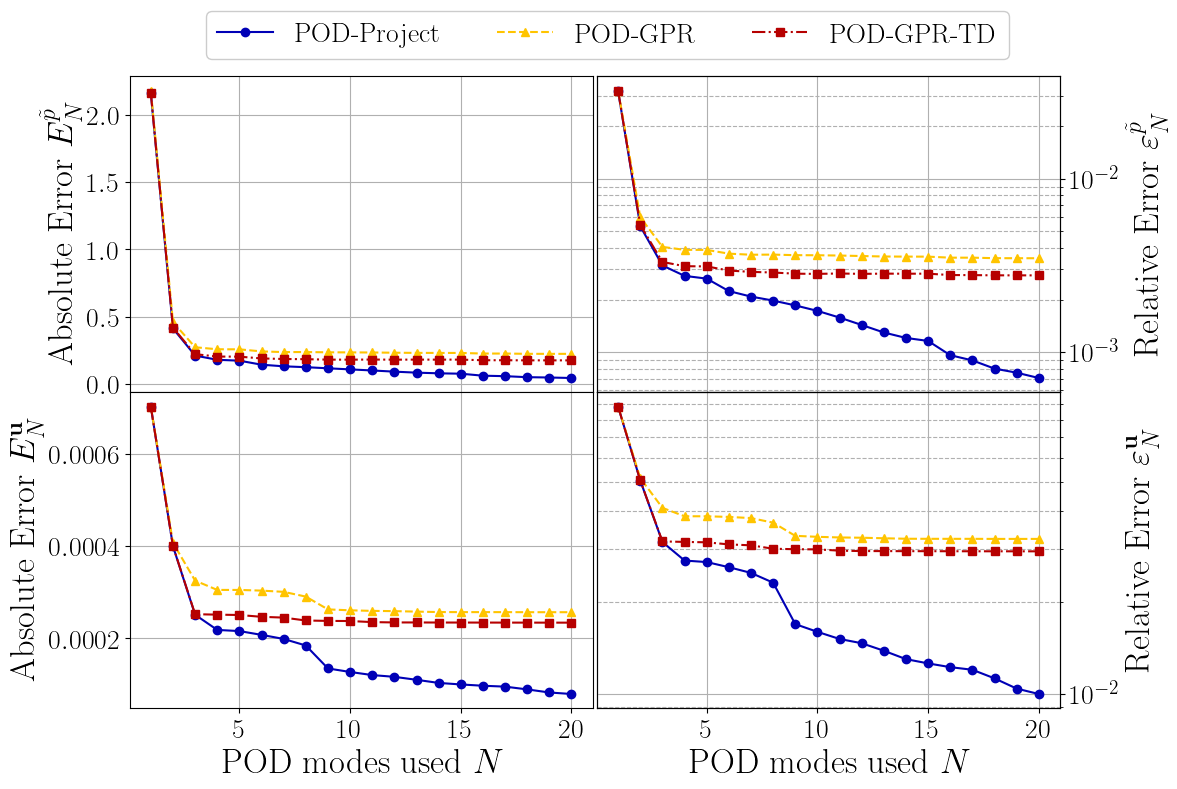

In [9]:
fig, axs = plt.subplots(nrows = 2, ncols = 2, sharex=True, figsize=(2 * 6, 2*4))

N_plot = np.arange(1, Nmax+1, 1)
fontsize  = 25
labelsize = 20

markers = ['o', '^', 's']
lines_style = ['-', '--', '-.']
colors = cm.jet([0.05, 0.7, 0.95])

for field_i in range(len(var_names)):
    
    ax2 = axs[field_i, 1].twinx()
    for ii, key in enumerate(list(test_errors.keys())):
        axs[field_i, 0].plot(N_plot, test_errors[key][field_i][0], markers[ii]+lines_style[ii], c=colors[ii], label=key)
        ax2.semilogy(N_plot, test_errors[key][field_i][1], markers[ii]+lines_style[ii], c=colors[ii], label=key)
        
    axs[field_i, 0].set_ylabel(r'Absolute Error $E_N^{'+tex_var_names[field_i]+r'}$', fontsize=fontsize)
    ax2.set_ylabel(r'Relative Error $\varepsilon_N^{'+tex_var_names[field_i]+r'}$', fontsize=fontsize)
    
    axs[field_i, 0].grid(which='major',linestyle='-')
    axs[field_i, 0].grid(which='minor',linestyle='--')
    axs[field_i, 1].set_yticks([])
    axs[field_i, 1].grid(which='major',linestyle='-')
    axs[field_i, 1].grid(which='minor',linestyle='--')   
    ax2.grid(which='major',linestyle='-')
    ax2.grid(which='minor',linestyle='--')   
    ax2.tick_params(axis='both', labelsize=labelsize)

for ax in axs.flatten():
    ax.tick_params(axis='both', labelsize=labelsize)
axs[1, 0].set_xlabel(r'POD modes used $N$', fontsize=fontsize)
axs[1, 1].set_xlabel(r'POD modes used $N$', fontsize=fontsize)    


Line, Label = axs[0,0].get_legend_handles_labels()    
fig.legend(Line, Label, framealpha = 1, fontsize=labelsize, loc=(0.175, 0.925), ncols=3)

fig.subplots_adjust(hspace = 0.0, wspace=0.01, top=0.9)
fig.savefig(path+'/OnlineTestError_global.pdf', format='pdf', dpi=300, bbox_inches='tight')

### Computational Costs

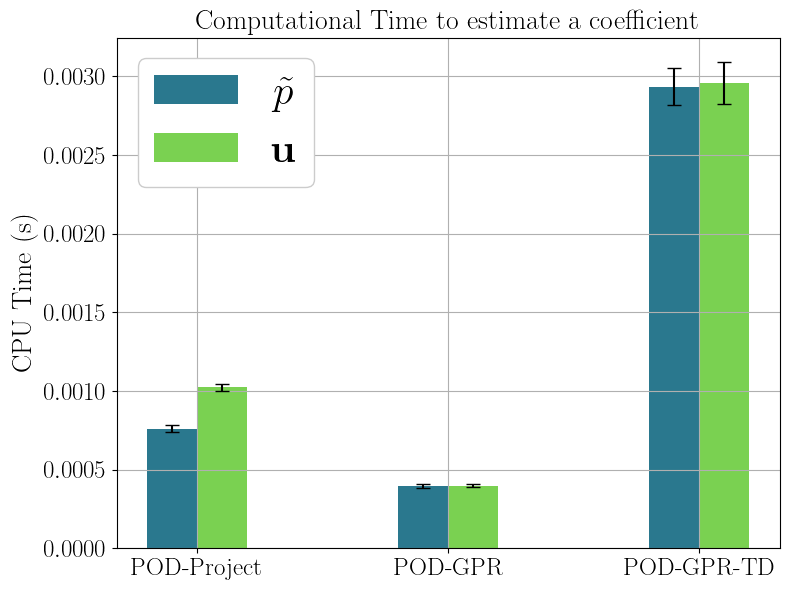

In [10]:
# Initialize subplots
fig, ax = plt.subplots(figsize=(8, 6))

# Iterate over field_i values
colors = plt.cm.viridis(np.linspace(0.4, 0.8, len(var_names)))  # Choose a colormap
for field_i, color in zip(range(len(var_names)), colors):
    means = []
    stds = []

    # Calculate mean and std for each key
    for key in list(test_errors.keys()):
        mean = np.mean(np.mean(test_errors[key][field_i][2]['CoeffEstimation'], axis=0))
        std = np.std(np.mean(test_errors[key][field_i][2]['CoeffEstimation'], axis=0))
        means.append(mean)
        stds.append(std)

    # Plot the bar chart with error bars for standard deviation
    bar_width = 0.2  # Adjust as needed
    ind = np.arange(len(list(test_errors.keys())))
    bars = ax.bar(ind + (field_i - len(var_names) / 4) * bar_width, means, bar_width, label=r'$'+tex_var_names[field_i]+'$', color=color, yerr=stds, capsize=5)

ax.set_ylabel(r'CPU Time (s)', fontsize=20)
ax.set_title(r'Computational Time to estimate a coefficient', fontsize=20)
ax.set_xticks(ind)
ax.set_xticklabels(list(test_errors.keys()))
ax.legend(framealpha=1, fontsize=30)
ax.tick_params(axis='both', labelsize=18)
ax.grid()


# Adjust layout and show the plot
plt.tight_layout()
plt.show()
fig.savefig(path+'/ComputationalTime.pdf', format='pdf', dpi=300, bbox_inches='tight')

## Reconstruction

In [11]:
path_of = './OpenFOAM_data/By/Test/'
param_list = [folder+'/' for folder in os.listdir(path_of) if os.path.isdir(os.path.join(path_of, folder))]
param_list.sort() 
param_list = [float(param_list[ii][1:5])/1000 for ii in range(len(param_list))]

### Detachment Length
Let us reshape the test snapshots

In [12]:
test_snaps_separated  = dict()
test_params_separated = dict()

for idx_p, param in enumerate(param_list):
    test_snaps_separated['By = {:.2f}'.format(param)]  = list()
    test_params_separated['By = {:.2f}'.format(param)] = list()
    
    for field_i in range(len(var_names)):
        test_snaps_separated['By = {:.2f}'.format(param)].append(FunctionsList(fun_spaces[field_i]))
        test_params_separated['By = {:.2f}'.format(param)].append(list())
        for mu in range(len(test_params[field_i])):
            if np.isclose(test_params[field_i][mu, 0], param_list[idx_p]):
                test_params_separated['By = {:.2f}'.format(param)][field_i].append(np.array(test_params[field_i][mu]))
                test_snaps_separated['By = {:.2f}'.format(param)][field_i].append(test_snaps[field_i](mu))
                
        test_params_separated['By = {:.2f}'.format(param)][field_i] = np.asarray(test_params_separated['By = {:.2f}'.format(param)][field_i])    

Let us now reconstruct the snapshots for post-process

In [13]:
from detachment_length import detach_x_bfs

Nmax = 10

detach_calculations = detach_x_bfs(domain)
detatch_rom = list()

for idx_By, By_to_plot in enumerate(param_list):

    reconstruction = {'recon': dict()}
    detatch_rom.append(dict())

    field_i = 1
        
    for key in list(test_errors.keys()):   
        reconstruction['recon'][key] = FunctionsList(fun_spaces[field_i])

    for mu in range(len(test_snaps_separated['By = {:.2f}'.format(By_to_plot)][field_i])):
        tmp = pod_proj_online[field_i].reconstruct(test_snaps_separated['By = {:.2f}'.format(By_to_plot)][field_i].map(mu), Nmax)
        reconstruction['recon']['POD-Project'].append(tmp[0])
        
        tmp = pod_gpr_online[field_i].reconstruct(test_snaps_separated['By = {:.2f}'.format(By_to_plot)][field_i](mu), test_params_separated['By = {:.2f}'.format(By_to_plot)][field_i][mu].reshape(-1,2), Nmax)
        reconstruction['recon']['POD-GPR'].append(tmp[0])
        
        tmp = pod_gpr_td_online[field_i].reconstruct(test_snaps_separated['By = {:.2f}'.format(By_to_plot)][field_i](mu), test_params_separated['By = {:.2f}'.format(By_to_plot)][field_i][mu].reshape(-1,2), Nmax)
        reconstruction['recon']['POD-GPR-TD'].append(tmp[0])
    
    for key in list(test_errors.keys()):  
        detatch_rom[idx_By][key] = detach_calculations.compute(reconstruction['recon'][key])
        
    del reconstruction

Let us compute the detachment length for the reconstructed field.

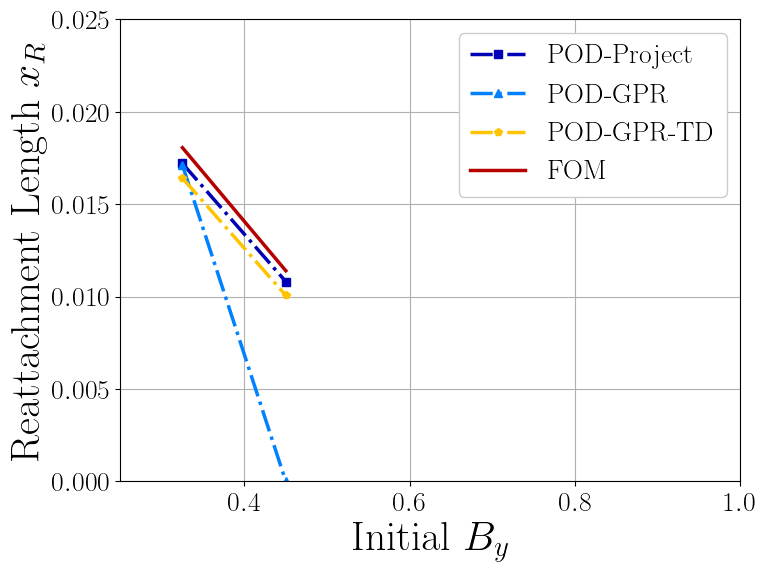

In [14]:
plot_detatch_rom = dict()

for key in list(test_errors.keys()):  
    plot_detatch_rom[key] = np.zeros_like(param_list)
    for idx_By in range(len(detatch_rom)):
        plot_detatch_rom[key][idx_By] = np.mean(detatch_rom[idx_By][key][25:])
        
mean_det = [np.mean(det[50:]) for det in detach_fom[1]]

fig = plt.figure(figsize=(8,6))

colors = cm.jet([0.05, 0.25, 0.7, 0.95])
ls = 2.5

plt.plot(param_list, plot_detatch_rom[list(test_errors.keys())[0]], 's-.', c=colors[0], linewidth = ls, label = list(test_errors.keys())[0])
plt.plot(param_list, plot_detatch_rom[list(test_errors.keys())[1]], '^-.', c=colors[1], linewidth = ls, label = list(test_errors.keys())[1])
plt.plot(param_list, plot_detatch_rom[list(test_errors.keys())[2]], 'p-.', c=colors[2], linewidth = ls, label = list(test_errors.keys())[2])

plt.plot(param_list, mean_det, '-', c=colors[3], linewidth = ls, label='FOM')

fontsize  =30
labelsize = 20
ax = fig.get_axes()
ax[0].tick_params(labelsize=labelsize)
plt.xlabel('Initial $B_y$', fontsize=fontsize)
plt.ylabel('Reattachment Length $x_R$', fontsize=fontsize)
plt.xticks(np.arange(0.2, 1.01,0.2))
plt.grid()
plt.xlim(0.25, 1)
plt.ylim(0, 0.025)
plt.legend(fontsize=labelsize, framealpha=1, loc='upper right')
fig.savefig(path+'/Reattach_Length.pdf', format='pdf', dpi=300, bbox_inches='tight')

### Contour Plotting

Here some auxiliary plotting functions are defined

In [15]:
def vector_grids(fun: dolfinx.fem.Function, mag_plot: bool, varname='u'):
    
    topology, cells, geometry = dolfinx.plot.create_vtk_mesh(fun.function_space)
    grid = pv.UnstructuredGrid(topology, cells, geometry)

    values = np.zeros((geometry.shape[0], 3))
    values[:, :len(fun)] = np.real(fun.x.array.reshape(geometry.shape[0], len(fun)))
    grid[varname] = values

    if mag_plot:
        warped = grid.warp_by_vector(varname, factor=0.0) 
    else:
        warped = grid.glyph(varname, factor=0.15, tolerance=0.02)
        
    return warped, values

def grids(fun: dolfinx.fem.Function):
    topology, cell_types, geometry = dolfinx.plot.create_vtk_mesh(fun.function_space)
    u_grid = pv.UnstructuredGrid(topology, cell_types, geometry)
    u_grid.point_data['fun'] = fun.x.array[:].real
    u_grid.set_active_scalars('fun')
    return u_grid

Here the actual function to plot is defined

In [38]:
def adjust_camera_pos(_plotter):
    # Adjust camera position
    camera_position = _plotter.camera.position
    focal_point = _plotter.camera.focal_point
    
    new_camera_position = (camera_position[0] + 0.045, camera_position[1], camera_position[2])
    new_focal_point = (focal_point[0] - 0.045, focal_point[1], focal_point[2])

    _plotter.camera.position = new_camera_position
    _plotter.camera.focal_point = new_focal_point

def PlotFOM_vs_ROM( fom: FunctionsList, rom: dict, mu: int, filename: str, title: str, varname: str,
                    clim = None, mag_plot = True, colormap = cm.jet, resolution= [1080, 720], 
                    colormap_res = cm.plasma_r, clim_res = None):  
    
    keys = list(rom.keys())
    
    resolution = [3600, 425 * ( len(keys) + 1)]
    plotter = pv.Plotter(shape=(len(keys)+1, 2), off_screen=False, border=False, window_size=resolution)
    
    lab_fontsize = 32
    title_fontsize = 40
    zoom = 8
    
    dict_cb = dict(title = varname, width = 0.75, height = 0.2,
                    title_font_size=title_fontsize,
                    label_font_size=lab_fontsize,
                    n_labels=4,
                    color = 'k',
                    position_x=0.125, position_y=0.75,
                    shadow=False) 
    
    if test_snaps[field_i].fun_space.num_sub_spaces > 0:
        vector_plot = True
    else:
        vector_plot = False
    
    ############################ FOMs ###################################

    plotter.subplot(0,0)
    
    # fom._list[mu] = fom._list[mu] * (umax - umin) + umin
    
    if vector_plot:
        warped_fom, values_fom = vector_grids(fom.map(mu), mag_plot, varname=varname)
        if clim is None:
            clim = [0., max(np.sqrt(values_fom[:, 0]**2+values_fom[:, 1]**2+values_fom[:, 2]**2))]
    else:
        warped_fom = grids(fom.map(mu))
        if clim is None:
            clim = [min(fom(mu)), max(fom(mu))]
        
    dict_cb['title'] = 'FOM - $'+varname+'$'
    plotter.add_mesh(warped_fom, clim = clim, cmap = colormap, show_edges=False, scalar_bar_args=dict_cb)
    plotter.view_xy()
    plotter.camera.zoom(zoom)
    adjust_camera_pos(plotter)

    ############################ ROMs ###################################


    for key_i in range(len(keys)):
        plotter.subplot(1+key_i,0)
        
        # rom[keys[key_i]]._list[mu] = rom[keys[key_i]]._list[mu] * (umax - umin) + umin
    
        if vector_plot:
            warped_rom, _ = vector_grids(rom[keys[key_i]].map(mu), mag_plot, varname=varname)
        else:
            warped_rom = grids(rom[keys[key_i]].map(mu))
        
        dict_cb['title'] = keys[key_i]+' - $'+varname+'$'
        plotter.add_mesh(warped_rom, clim = clim, cmap = colormap, show_edges=False, scalar_bar_args=dict_cb)
        plotter.view_xy()
        plotter.camera.zoom(zoom)
        adjust_camera_pos(plotter)

    ############################ Residuals ###################################

    max_res = 0.
    for key_i in range(len(keys)):
        plotter.subplot(1+key_i,1)
        
        residual = Function(rom[keys[key_i]].fun_space)
        residual.x.array[:] = np.abs(rom[keys[key_i]](mu) - fom(mu))

        max_res = max([max_res, max(residual.x.array[:])])
        
        if vector_plot:
            warped_rom, _ = vector_grids(residual, mag_plot, varname=varname)
        else:
            warped_rom = grids(residual)
        
        if clim_res is None:
            clim_res = [0, max_res * 1.1]
        
        dict_cb['title'] = 'Residual '+keys[key_i]+' - $'+varname+'$'
        plotter.add_mesh(warped_rom, clim = clim_res, cmap = colormap_res, show_edges=False, scalar_bar_args=dict_cb)
        plotter.view_xy()
        plotter.camera.zoom(zoom)
        adjust_camera_pos(plotter)

    plotter.set_background('white', top='white')
    plotter.add_text(str(title), color= 'k', position=[50, 40], font_size=30)
        
    ## Save figure
    plotter.screenshot(filename+'.png', transparent_background = True,  window_size=resolution)
    plotter.close()

Let us now plot the Full Order solution versus the ROM reconstructions

In [39]:
from tqdm import tqdm

path_=path+'Pv_figs/'
if not os.path.exists(path_):
    os.makedirs(path_)

idx_By = 0
By_to_plot = param_list[idx_By]

Nmax = 10

reconstruction = {'recon': list(), 'resid': list()}

for field_i in range(len(var_names)):
    reconstruction['recon'].append(dict())
    reconstruction['resid'].append(dict())
    
for field_i in range(len(var_names)):
    
    for key in list(test_errors.keys()):   
        reconstruction['recon'][field_i][key] = FunctionsList(fun_spaces[field_i])
        reconstruction['resid'][field_i][key] = FunctionsList(fun_spaces[field_i])
    
    for mu in range(len(test_snaps_separated['By = {:.2f}'.format(By_to_plot)][field_i])):
        tmp = pod_proj_online[field_i].reconstruct(test_snaps_separated['By = {:.2f}'.format(By_to_plot)][field_i].map(mu), Nmax)
        reconstruction['recon'][field_i]['POD-Project'].append(tmp[0])
        reconstruction['resid'][field_i]['POD-Project'].append(tmp[1])
        
        tmp = pod_gpr_online[field_i].reconstruct(test_snaps_separated['By = {:.2f}'.format(By_to_plot)][field_i](mu), test_params_separated['By = {:.2f}'.format(By_to_plot)][field_i][mu].reshape(-1,2), Nmax)
        reconstruction['recon'][field_i]['POD-GPR'].append(tmp[0])
        reconstruction['resid'][field_i]['POD-GPR'].append(tmp[1])
        
        tmp = pod_gpr_td_online[field_i].reconstruct(test_snaps_separated['By = {:.2f}'.format(By_to_plot)][field_i](mu), test_params_separated['By = {:.2f}'.format(By_to_plot)][field_i][mu].reshape(-1,2), Nmax)
        reconstruction['recon'][field_i]['POD-GPR-TD'].append(tmp[0])
        reconstruction['resid'][field_i]['POD-GPR-TD'].append(tmp[1])

    # Plotting
    
    # for tt_plot in tqdm(range(len(test_snaps_separated['By = {:.2f}'.format(By_to_plot)][field_i]))):
    # for tt_plot in tqdm(np.hstack([np.arange(1,25,1), np.array([49]), np.array([59])])):
    for tt_plot in tqdm(np.hstack([np.array([49]), np.array([59])])):

        title = 'Time = {:.2f}'.format(test_params[field_i][tt_plot, 1])+' s - $B_y$ = {:.3f}'.format(By_to_plot)+' T'
        
        if field_i == 0:
            PlotFOM_vs_ROM( test_snaps_separated['By = {:.2f}'.format(By_to_plot)][field_i],
                            reconstruction['recon'][field_i], 
                            tt_plot,
                            path_+var_names[field_i]+'_mag_By_'+str(idx_By)+'_t_'+str(tt_plot), title=title, varname=tex_var_names[field_i],
                            mag_plot=False,
                            colormap=cm.rainbow,
                            clim = [0, 2000],
                            colormap_res = cm.plasma_r, 
                            )
        elif field_i == 1:
            PlotFOM_vs_ROM( test_snaps_separated['By = {:.2f}'.format(By_to_plot)][field_i],
                            reconstruction['recon'][field_i], 
                            tt_plot,
                            path_+var_names[field_i]+'_mag_By_'+str(idx_By)+'_t_'+str(tt_plot), title=title, varname=tex_var_names[field_i],
                            mag_plot=True,
                            colormap=cm.RdYlBu,
                            clim = [0, 0.5],
                            colormap_res = cm.magma_r)